# Exploratory Data Analysis

This notebook explores the cleaned traffic data by summarizing roads, stations, traffic volumes, and vehicle composition. It highlights the distribution of observations and identifies patterns that are important for later trend analysis and bottleneck detection.

### Step 3: Explore key traffic patterns
This section summarizes the data distribution, road coverage, and traffic characteristics.

In [1]:
# ======================================================
# Phase 2
# Exploratory Data Analysis
# German Autobahn Traffic Dataset
# ======================================================

In [26]:
# Explore the dataset and summarize traffic patterns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [27]:
# Explore the dataset and summarize traffic patterns
df = pd.read_csv("../data/traffic_cleaned_final.csv")

print(df.shape)

(34451, 252)


C:\Users\vikhy\AppData\Local\Temp\ipykernel_15080\3462123713.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


In [ ]:
# Explore the dataset and summarize traffic patterns
#AI prompt : for this cleaned dataset generate a summary report with number of rows, columns, missing values, duplicate rows and data types
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print(f"Rows        : {len(df)}")
print(f"Columns     : {len(df.columns)}")
print(f"Years       : {df['Jahr'].nunique()}")
print(f"Roads       : {df['Str_Nr'].nunique()}")
print(f"Stations    : {df['DZ_Name'].nunique()}")
print(f"States      : {df['Land_Code'].nunique()}")

DATASET SUMMARY
Rows        : 34451
Columns     : 252
Years       : 21
Roads       : 323
Stations    : 2273
States      : 16


In [29]:
#number of unique stations per state
state_counts = (
    df.groupby("Land_Code")["DZ_Name"]
      .nunique()
      .sort_values(ascending=False)
)

display(state_counts)

Land_Code
BY    390
NW    347
HE    326
RP    201
NI    182
BW    154
ST    108
SH    101
TH     99
BB     90
SN     80
SL     79
MV     71
HH     23
BE     19
HB      7
Name: DZ_Name, dtype: int64

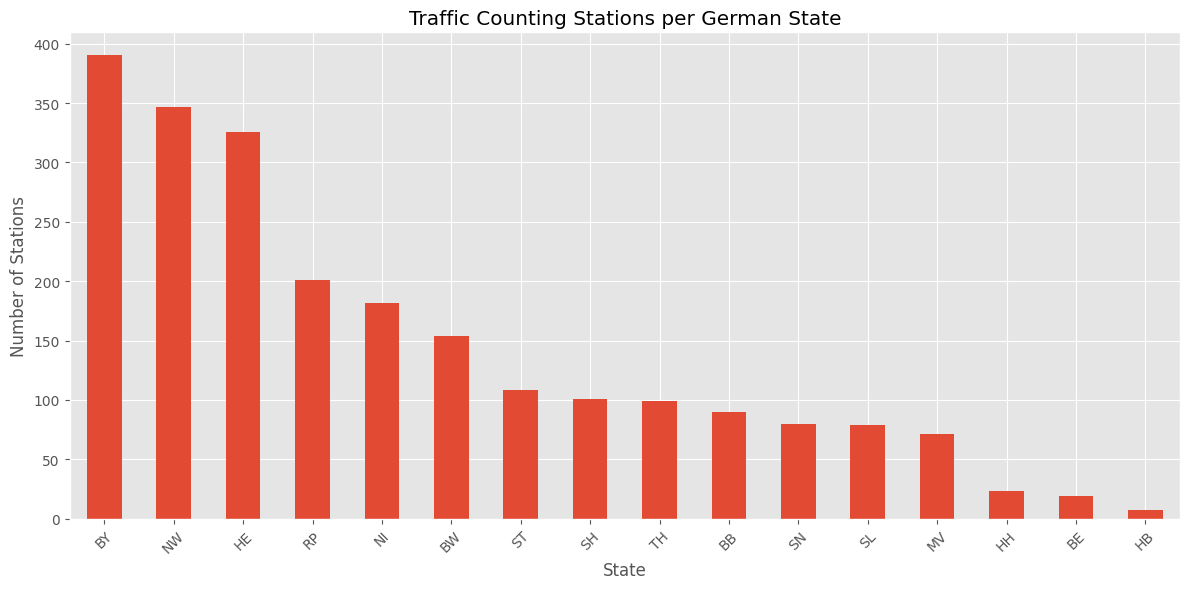

In [30]:
#plot state
plt.figure(figsize=(12,6))

state_counts.plot(kind="bar")

plt.title("Traffic Counting Stations per German State")

plt.xlabel("State")

plt.ylabel("Number of Stations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [31]:
#top 20 roads
road_counts = (
    df.groupby("Str_Nr")["DZ_Name"]
      .nunique()
      .sort_values(ascending=False)
      .head(20)
)

display(road_counts)

Str_Nr
3     127
8      88
9      83
6      80
7      80
4      71
1      69
2      69
5      66
61     46
66     40
45     35
73     33
71     31
14     28
38     27
96     25
70     24
27     24
31     24
Name: DZ_Name, dtype: int64

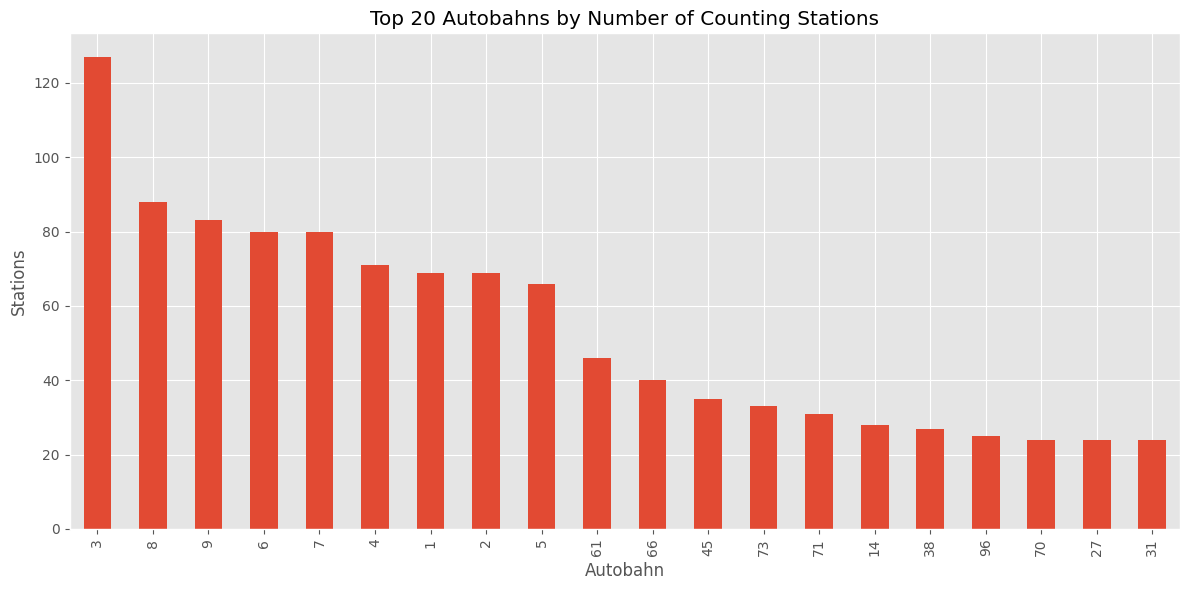

In [32]:
# Explore the dataset and summarize traffic patterns
plt.figure(figsize=(12,6))

road_counts.plot(kind="bar")

plt.title("Top 20 Autobahns by Number of Counting Stations")

plt.xlabel("Autobahn")

plt.ylabel("Stations")

plt.tight_layout()

plt.show()

In [33]:
#number of records per year
year_counts = (
    df["Jahr"]
    .value_counts()
    .sort_index()
)

display(year_counts)

Jahr
2003    1260
2004    1293
2005    1321
2006    1331
2007    1339
2008    1345
2009    1375
2010    1460
2011    1482
2012    1494
2013    1503
2014    1683
2015    1746
2016    1747
2017    1753
2018    1924
2019    2016
2020    2040
2021    2109
2022    2114
2023    2116
Name: count, dtype: int64

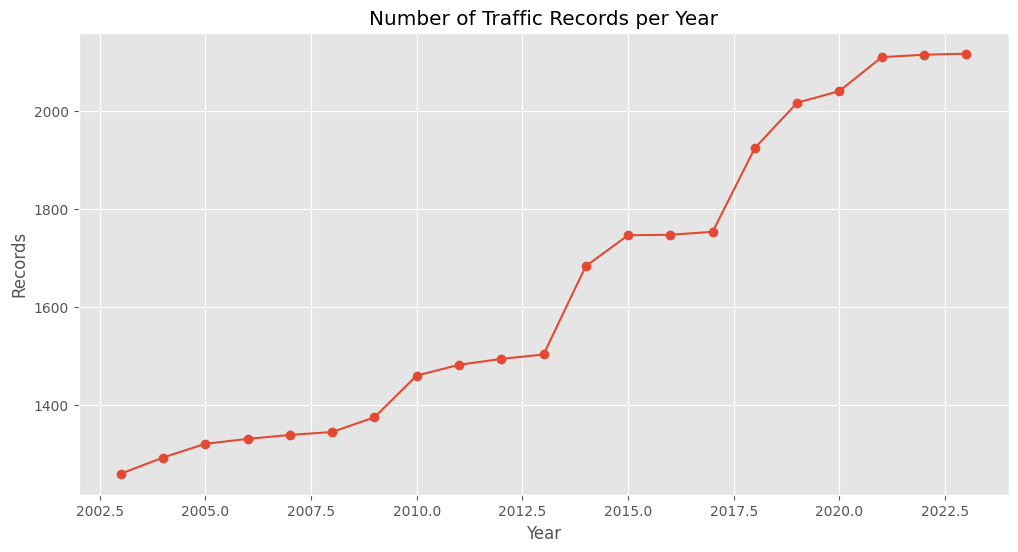

In [ ]:
# Explore the dataset and summarize traffic patterns
# AI-assisted: generate a line plot to visualize the number of traffic records per year
plt.figure(figsize=(12,6))

year_counts.plot(marker="o")

plt.title("Number of Traffic Records per Year")

plt.xlabel("Year")

plt.ylabel("Records")

plt.grid(True)

plt.show()

In [35]:
#most common roads in the dataset
road_frequency = (
    df["Str_Nr"]
    .value_counts()
    .head(15)
)

display(road_frequency)

Str_Nr
3     1858
9     1339
8     1213
6     1177
7     1104
1     1079
4      944
2      936
5      842
61     768
27     458
73     456
14     455
96     358
10     355
Name: count, dtype: int64

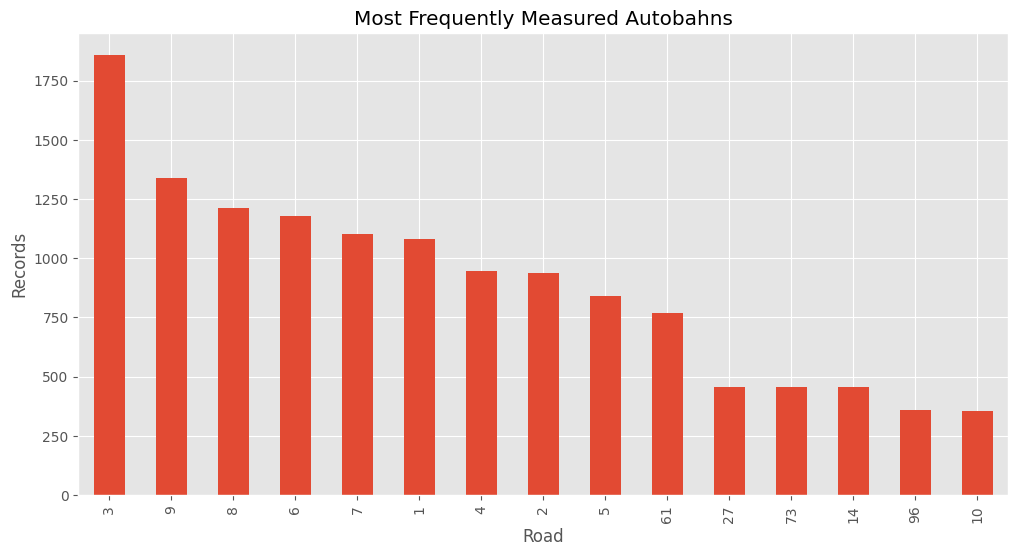

In [36]:
# Explore the dataset and summarize traffic patterns
plt.figure(figsize=(12,6))

road_frequency.plot(kind="bar")

plt.title("Most Frequently Measured Autobahns")

plt.xlabel("Road")

plt.ylabel("Records")

plt.show()

In [13]:
# Explore the dataset and summarize traffic patterns
traffic = df["DTV_Kfz_W_Q"].dropna()

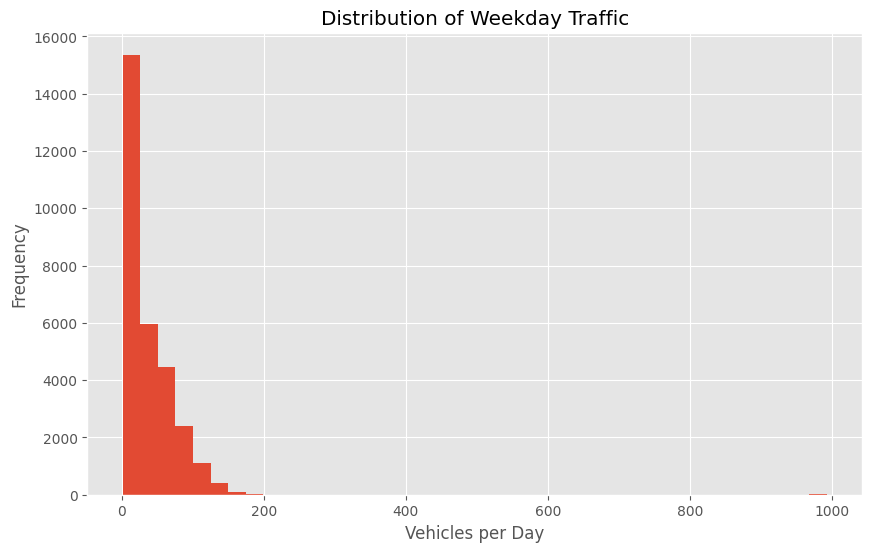

In [14]:
# Explore the dataset and summarize traffic patterns
plt.figure(figsize=(10,6))

plt.hist(
    traffic,
    bins=40
)

plt.title("Distribution of Weekday Traffic")

plt.xlabel("Vehicles per Day")

plt.ylabel("Frequency")

plt.show()

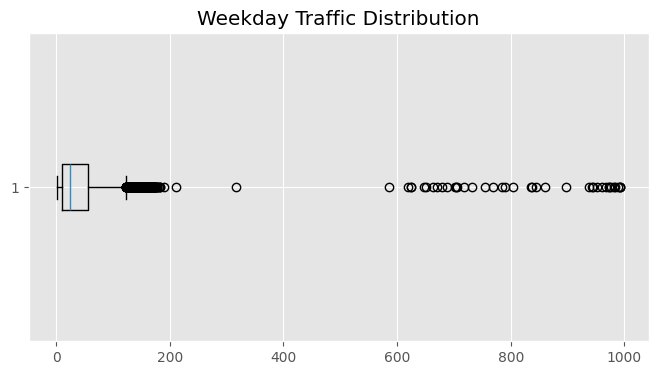

In [ ]:
# Explore the dataset and summarize traffic patterns
#AI prompt : for this create a weekday Traffic distribution boxplot
plt.figure(figsize=(8,4))

plt.boxplot(
    traffic,
    vert=False
)

plt.title("Weekday Traffic Distribution")

plt.show()

In [38]:
# Explore the dataset and summarize traffic patterns
traffic.describe()

count    29827.000000
mean        37.356359
std         43.729295
min          1.002000
25%         10.150000
50%         24.269000
75%         55.426000
max        993.000000
Name: DTV_Kfz_W_Q, dtype: float64

In [39]:
#ake the station name and traffic columns, sort the stations from highest traffic to lowest traffic, keep only the top 20 stations, and display them.
top20 = (
    df[
        ["DZ_Name","DTV_Kfz_W_Q"]
    ]
    .sort_values(
        "DTV_Kfz_W_Q",
        ascending=False
    )
    .head(20)
)

display(top20)

,DZ_Name,DTV_Kfz_W_Q
6203,Fladungen,993.0
33096,Fladungen,993.0
15699,Fladungen,992.0
29144,Fladungen,988.0
25072,Fladungen,984.0
19127,Fladungen,982.0
30217,Rathsfeld,977.0
3945,Teldau,973.0
19176,Dockweiler,973.0
31797,Fladungen,967.0


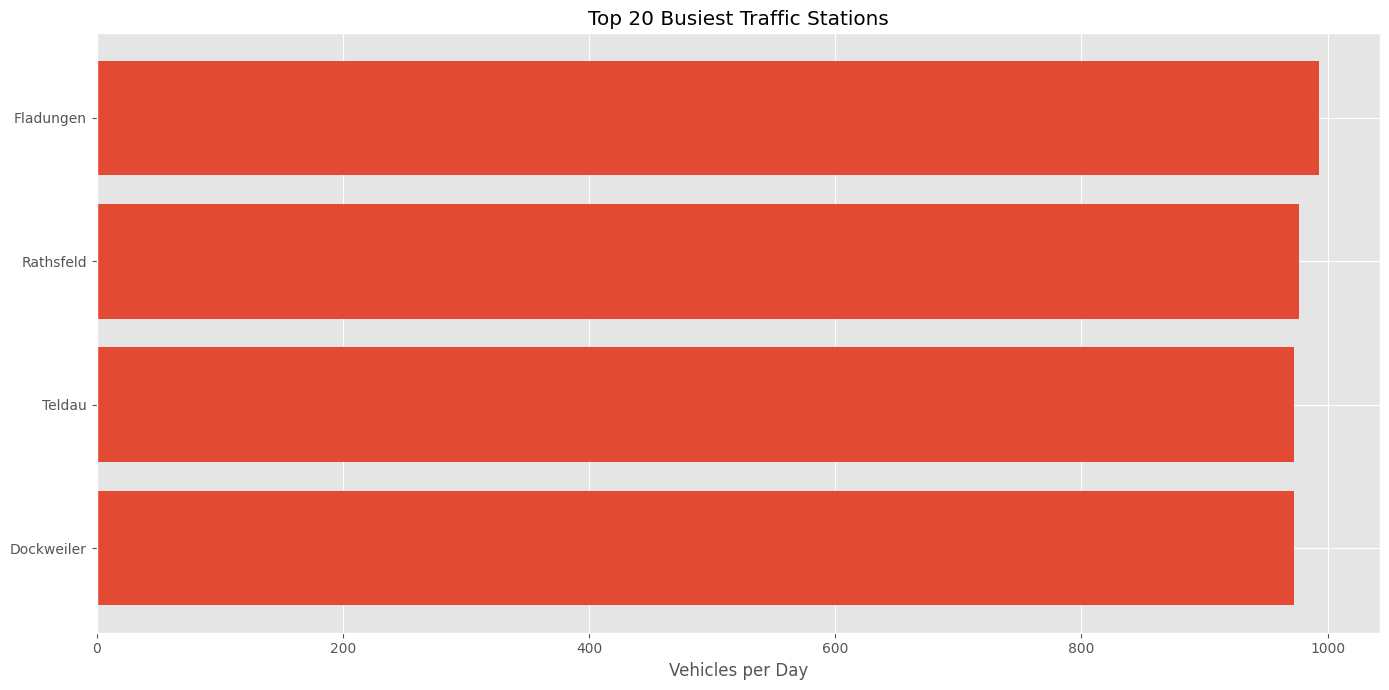

In [ ]:
# Explore the dataset and summarize traffic patterns
#AI usage : asked to generate a bar chart for the top 20 busiest traffic stations
plt.figure(figsize=(14,7))

plt.barh(
    top20["DZ_Name"],
    top20["DTV_Kfz_W_Q"]
)

plt.title("Top 20 Busiest Traffic Stations")

plt.xlabel("Vehicles per Day")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

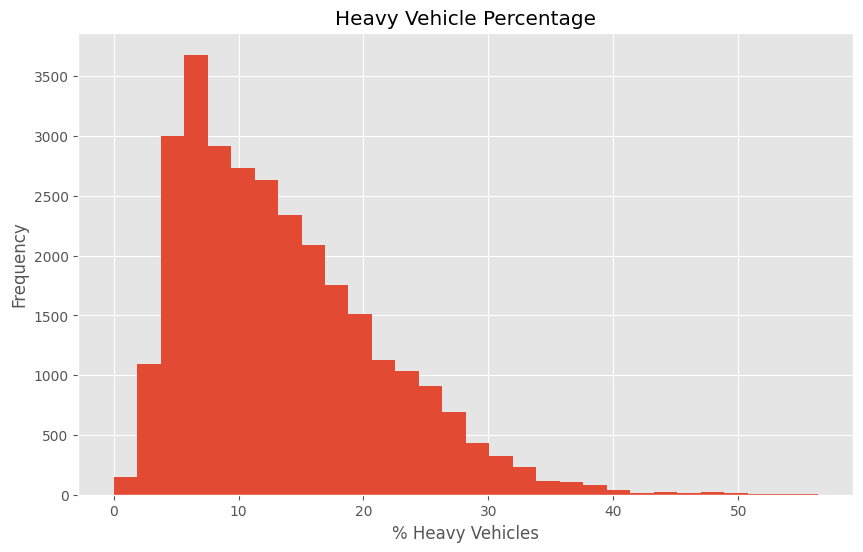

In [41]:
# Explore the dataset and summarize traffic patterns
plt.figure(figsize=(10,6))

plt.hist(
    df["pSV_W_Q"].dropna(),
    bins=30
)

plt.title("Heavy Vehicle Percentage")

plt.xlabel("% Heavy Vehicles")

plt.ylabel("Frequency")

plt.show()

In [42]:
#top roads
top_roads = (
    df.groupby("Str_Nr")
      ["DTV_Kfz_W_Q"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

display(top_roads)

Str_Nr
498    628.916667
285    244.882700
410    136.624538
85     112.791700
100    107.377410
99      97.534173
113     85.360379
559     83.983000
661     80.026360
555     77.723095
40      75.195291
67      73.378435
648     71.768607
3       70.667736
565     69.664167
Name: DTV_Kfz_W_Q, dtype: float64

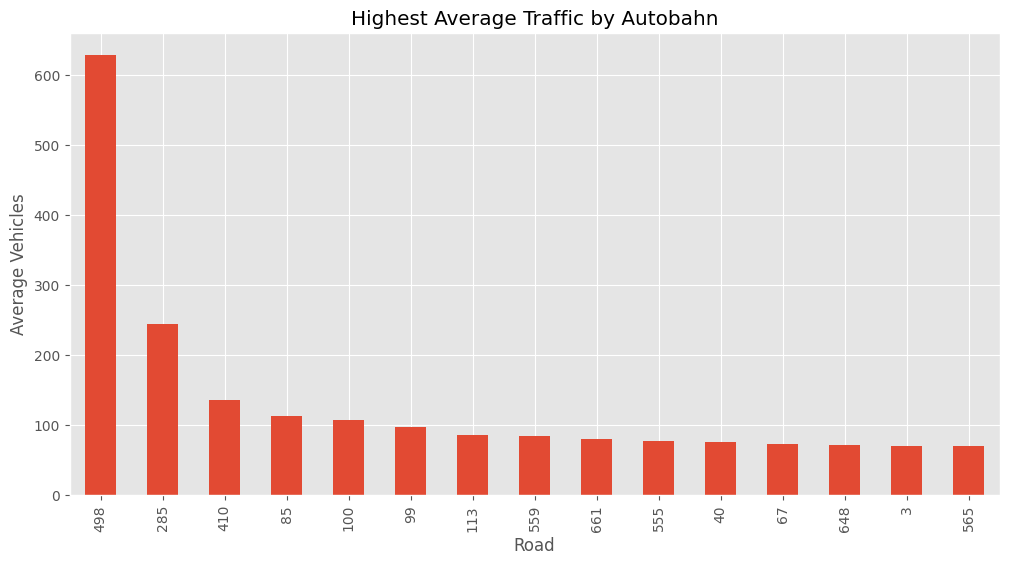

In [43]:
# Explore the dataset and summarize traffic patterns
plt.figure(figsize=(12,6))

top_roads.plot(kind="bar")

plt.title("Highest Average Traffic by Autobahn")

plt.ylabel("Average Vehicles")

plt.xlabel("Road")

plt.show()

In [44]:
#traffic by state
state_traffic = (
    df.groupby("Land_Code")
      ["DTV_Kfz_W_Q"]
      .mean()
      .sort_values(ascending=False)
)

display(state_traffic)

Land_Code
HB    75.452279
BE    69.052455
HH    62.810953
NW    49.181845
BY    46.808616
HE    45.987779
BW    37.649414
RP    36.230957
NI    30.380454
TH    29.312565
SL    27.939231
SN    26.335282
SH    22.217000
ST    20.117165
BB    16.157097
MV    13.128620
Name: DTV_Kfz_W_Q, dtype: float64

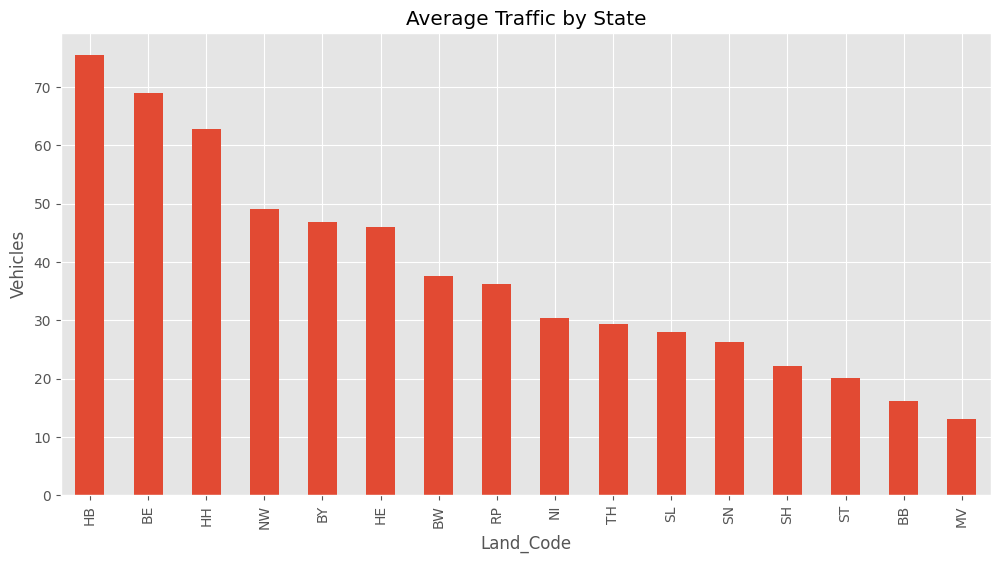

In [ ]:
# Explore the dataset and summarize traffic patterns
#AI : fix the labels making it look understanding 
plt.figure(figsize=(12,6))

state_traffic.plot(kind="bar")

plt.title("Average Traffic by State")

plt.ylabel("Vehicles")

plt.show()

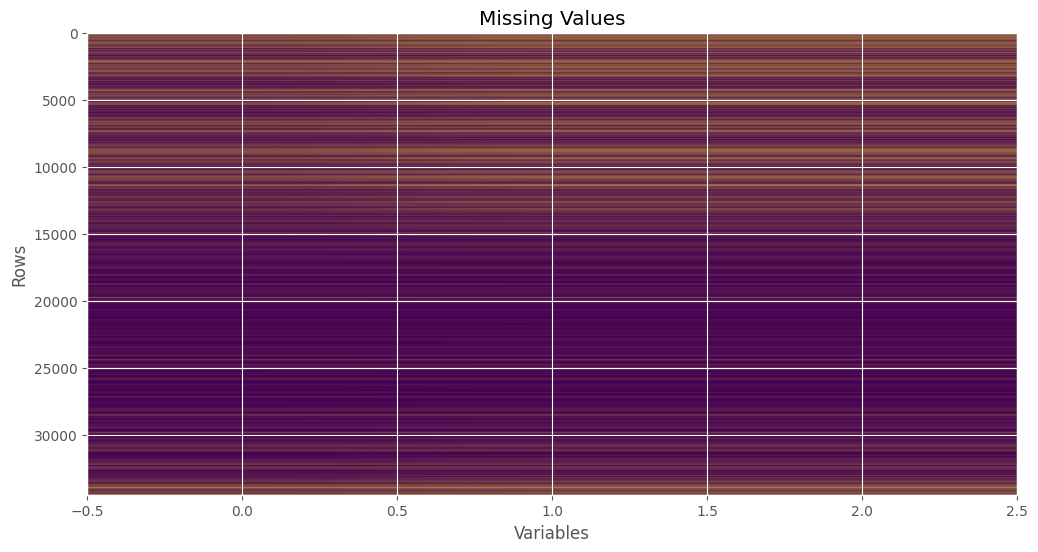

In [ ]:
#missing values heatmap
#AI prompt : give me a heatmap of missing values for the columns DTV_Kfz_W_Q, DTV_SV_W_Q, pSV_W_Q
missing = (
    df[
        [
            "DTV_Kfz_W_Q",
            "DTV_SV_W_Q",
            "pSV_W_Q"
        ]
    ]
    .isnull()
)

plt.figure(figsize=(12,6))

plt.imshow(
    missing,
    aspect="auto"
)

plt.title("Missing Values")

plt.xlabel("Variables")

plt.ylabel("Rows")

plt.show()